# Évolution de l'architecture sous drift — graphe neuromorphique

Contrairement à la visualisation des résultats, ce GIF montre l'évolution de la **STRUCTURE** :

- **Nœuds** = neurones d'ancrage (colorés par classe dominante, gris = libres, taille ∝ flux)
- **Arêtes** = **connexions de co-activation** (nb de fois que deux neurones gagnent ensemble sur la même image) — les vraies connexions neuromorphiques
- **Élagage Physarum** : les neurones sous-utilisés sont atrophiés (redeviennent gris/isolés), leurs connexions disparaissent

À chaque phase du drift, le graphe se réorganise : de nouvelles connexions apparaissent vers les nouveaux chiffres, d'autres s'atrophient.

## 0. Imports

In [1]:
# Évolution de l'ARCHITECTURE : graphe de co-activation neuromorphique
import os
import io
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from PIL import Image
from recherche_agi import (load_mnist, AnchorNeurons, dynamic_k)

## 1. Données + helpers

In [2]:
train_set, test_set = load_mnist()
os.makedirs('figs', exist_ok=True)

def latent(img_np):
    img = img_np.flatten()
    return img / (np.linalg.norm(img) + 1e-8)

CLASS_COLORS = ['#e6194b','#3cb44b','#ffe119','#4363d8','#f58231',
                '#911eb4','#46f0f0','#f032e6','#bcf60c','#fabebe']
FREE_COLOR = '#cccccc'

def make_graph_frame(anchors, label, pruned_total):
    n = anchors.n_neurons
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)
    pos = np.stack([np.cos(theta), np.sin(theta)], axis=1)
    colors = []
    for i in range(n):
        cls = anchors.labels_seen.get(i, {})
        if cls:
            dom = max(cls.items(), key=lambda x: x[1])[0]
            colors.append(CLASS_COLORS[dom])
        else:
            colors.append(FREE_COLOR)
    sizes = 30 + 250 * (anchors.activations / (anchors.activations.max()+1e-8))
    fig, ax = plt.subplots(figsize=(10, 9))
    co = anchors.co_act
    max_co = co.max() if co.max() > 0 else 1.0
    for i in range(n):
        for j in range(i+1, n):
            wgt = co[i, j]
            if wgt > 0.15 * max_co:
                alpha = min(0.9, 0.3 + 0.6 * wgt / max_co)
                lw = 0.5 + 3 * wgt / max_co
                ax.plot([pos[i,0], pos[j,0]], [pos[i,1], pos[j,1]],
                        color='#333333', alpha=alpha, linewidth=lw)
    ax.scatter(pos[:,0], pos[:,1], c=colors, s=sizes, edgecolors='black', linewidth=0.5, zorder=3)
    handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=CLASS_COLORS[d], markersize=8, label=str(d)) for d in range(10)]
    handles.append(plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=FREE_COLOR, markersize=8, label='libre'))
    ax.legend(handles=handles, loc='upper right', fontsize=6, ncol=3)
    ax.set_title(f"{label}\nactifs {len(anchors.labels_seen)}/{n} | connexions={int((co>0.15*max_co).sum()//2)} | élagués cumulés={pruned_total}", fontsize=11)
    ax.set_aspect('equal'); ax.axis('off')
    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=70); plt.close(fig)
    buf.seek(0)
    return np.array(Image.open(buf).convert('RGB'))

## 2. Protocole drift + snapshots du graphe + GIF

In [3]:
anchors = AnchorNeurons(d_in=784, n_neurons=40, seed=0, lr=0.1, use_homeostasis=True)
frames = []; pruned_total = 0

# Phase 1 : 0/1
cnt = [0]*10; presented = 0
snapshot_targets = [50, 200, 400]; si = 0
for i in range(len(train_set)):
    l = int(train_set[i][1])
    if l > 1 or cnt[l] >= 200: continue
    anchors.learn(latent(train_set[i][0].squeeze().numpy()), k=dynamic_k(0.5,1,5), label=l)
    cnt[l] += 1; presented += 1
    if si < len(snapshot_targets) and presented >= snapshot_targets[si]:
        frames.append(make_graph_frame(anchors, f"Phase 1 : 0/1 ({presented} img)", pruned_total))
        si += 1
    if sum(cnt[:2]) >= 400: break

# Phase 2 : 2-9 avec élagage Physarum
for new_digit in range(2, 10):
    shown = 0
    for i in range(len(train_set)):
        l = int(train_set[i][1])
        if l != new_digit: continue
        anchors.learn(latent(train_set[i][0].squeeze().numpy()), k=dynamic_k(0.5,1,5), label=l)
        shown += 1
        if shown >= 60: break
    n_pr = anchors.physarum_prune(0.15)
    pruned_total += n_pr
    frames.append(make_graph_frame(anchors, f"Phase 2 : intro {new_digit} (élagage {n_pr})", pruned_total))

print(f"Frames : {len(frames)}")
for i, f in enumerate(frames):
    imageio.imwrite(f'figs/graph_frame_{i:02d}.png', f)
imageio.mimsave('figs/graph_evolution.gif', frames, duration=0.8)
print("GIF : figs/graph_evolution.gif")

Frames : 11


GIF : figs/graph_evolution.gif


## 3. Le GIF de l'architecture

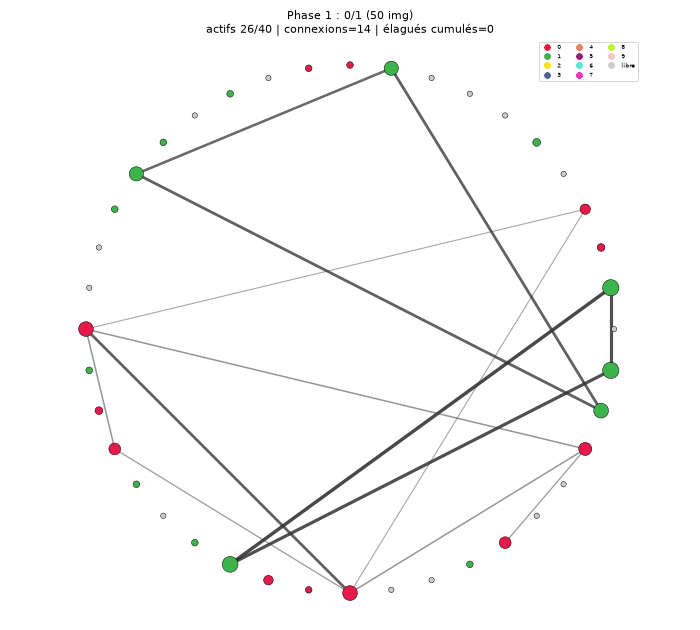

In [4]:
from IPython.display import Image as IPImage
display(IPImage(filename='figs/graph_evolution.gif'))

## 4. Ce qu'on observe

- **Phase 1 (0/1)** : seuls des nœuds rouges (0) et verts (1) apparaissent, avec des connexions entre eux ; les autres sont gris (libres).
- **Phase 2 (2-9)** : à chaque chiffre introduit, de **nouveaux nœuds colorés** apparaissent (2=jaune, 3=violet, 5=rose...), avec de **nouvelles connexions de co-activation** vers ces classes.
- **Élagage Physarum** : à chaque introduction, des neurones sous-utilisés sont **atrophiés** (redeviennent gris) et leurs connexions **disparaissent** — libérant du budget.

Le graphe se **réorganise en continu** : consolidation des connexions utiles, atrophie des inutiles. C'est l'**évolution de l'architecture**, pas des résultats.